In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -------------------------------
# 1. Trouver le chemin du fichier
# -------------------------------
def find_file(filename):
    """
    Cherche le fichier dans le répertoire courant et ses parents
    jusqu'à trouver un dossier 'data/processed' contenant le fichier.
    """
    current = os.getcwd()
    while True:
        test_path = os.path.join(current, 'data', 'processed', filename)
        if os.path.exists(test_path):
            return test_path
        parent = os.path.dirname(current)
        if parent == current:  # On est à la racine du disque
            raise FileNotFoundError(f"Fichier {filename} introuvable.")
        current = parent

# Chemin absolu vers final_data.csv
file_path = find_file('final_data.csv')
print(f"Chargement du fichier : {file_path}")

# Chargement
df = pd.read_csv(file_path)

# Affichage rapide
print("Aperçu des données :")
df.head()

Chargement du fichier : c:\Users\SEOGO MOUSSA\Documents\projet-insécurité-alimentaire\data\processed\final_data.csv
Aperçu des données :


,region,year,production,pluviometrie,superficie,risque
0,Boucle du Mouhoun,2020,127153.0,783.4,185829.0,0
1,Cascades,2020,94621.0,1146.0,105053.0,0
2,Centre,2020,141549.0,973.2,244207.0,0
3,Centre-Est,2020,94411.0,516.9,157128.0,0
4,Centre-Nord,2020,79061.0,733.0,124098.0,0


✅ Connexion à MongoDB réussie
🔧 Vérification de la base de données...
✅ Données chargées depuis MongoDB : 78 lignes
Colonnes disponibles : ['region', 'year', 'production', 'pluviometrie', 'superficie', 'risque']

📊 Statistiques descriptives :
          production  pluviometrie     risque
count      78.000000     78.000000  78.000000
mean   102615.461538    862.992308   0.038462
std     39245.870907    224.152821   0.251866
min     48738.000000    338.200000   0.000000
25%     76179.750000    725.550000   0.000000
50%     85547.500000    845.100000   0.000000
75%    123549.750000   1009.300000   0.000000
max    221020.000000   1361.900000   2.000000

📈 Matrice de corrélation :
              production  pluviometrie    risque
production      1.000000      0.580864  0.246019
pluviometrie    0.580864      1.000000  0.158799
risque          0.246019      0.158799  1.000000


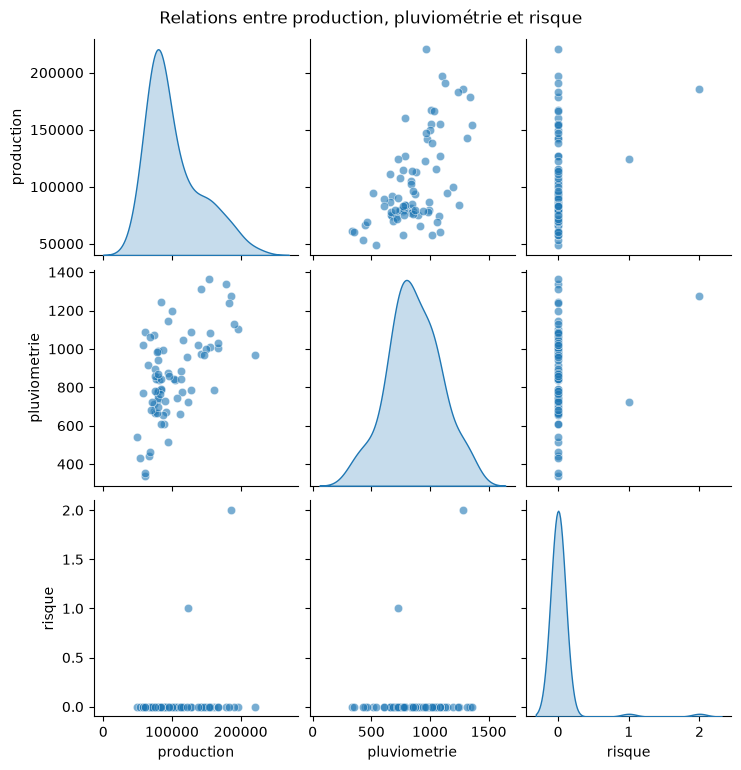

In [ ]:
# ---- Correction du chemin d'import ----
import sys
import os
 
# On remonte d'un niveau pour atteindre la racine du projet.
project_root = os.path.dirname(os.getcwd())

if project_root not in sys.path:
    sys.path.append(project_root)
from models.database import get_aggregated_data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Charger les données depuis MongoDB
df = get_aggregated_data()

# Vérifier si des données ont été chargées
if df.empty:
    print("❌ Aucune donnée trouvée dans MongoDB. Veuillez d'abord importer les données.")
    print("   Exécutez : python import_and_analyze.py")
    exit()
else:
    print(f"✅ Données chargées depuis MongoDB : {len(df)} lignes")

# 2. Vérifier les colonnes disponibles
print("Colonnes disponibles :", df.columns.tolist())

# 3. Sélectionner les colonnes utiles (celles qui existent réellement)
# Vos colonnes : region, year, production, pluviometrie, risque
df_viz = df[['region', 'year', 'production', 'pluviometrie', 'risque']].copy()

# 4. Afficher quelques statistiques
print("\n📊 Statistiques descriptives :")
print(df_viz[['production', 'pluviometrie', 'risque']].describe())

# 5. Afficher la matrice de corrélation
print("\n📈 Matrice de corrélation :")
print(df_viz[['production', 'pluviometrie', 'risque']].corr())

# 6. Visualisation (pairplot)
sns.pairplot(df_viz[['production', 'pluviometrie', 'risque']], 
             diag_kind='kde', 
             plot_kws={'alpha':0.6})
plt.suptitle("Relations entre production, pluviométrie et risque", y=1.02)
plt.show()